In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%autosave 0
    
import logging
logging.basicConfig(format='%(asctime)s %(levelname)s:%(message)s', level=logging.DEBUG, datefmt='%I:%M:%S')

import os
import sys
import numpy as np
import pandas as pd
import uuid
import time
import copy
import sdata
#lets find databe.py
modulepath = os.path.dirname(os.getcwd())
sys.path.insert(0, os.path.abspath(os.path.join(modulepath)))

from sdata.contrib.simple_graph_db import Database

Autosave disabled


09:49:40 DEBUG:Loaded backend module://ipykernel.pylab.backend_inline version unknown.


## graph examples
http://www.graphviz.org/doc/info/attrs.html

In [2]:
import pygraphviz as pgv
from IPython.display import Image

def draw(dot):
    return Image(pgv.AGraph(dot).draw(format='png', prog='dot'))
def draw_graph(g):
    return Image(g.draw(format='png', prog='dot'))
def draw_graph_svg(g):
    return Image(g.draw(format='svg', prog='dot'))

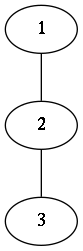

In [3]:
d={'1': {'2': None}, '2': {'1': None, '3': None}, '3': {'2': None}}
A=pgv.AGraph(d)
g=A.string()
draw_graph(A)

strict graph "" {
	graph [bb="0,0,150,92",
		ranksep=0.1
	];
	node [label="\N"];
	1	 [color=red,
		height=0.5,
		pos="123,74",
		shape=rect,
		width=0.75];
	b	 [height=0.5,
		pos="27,28.639",
		width=0.75];
	c	 [height=0.5,
		pos="98.21,18",
		width=0.75];
	b -- c	 [color=blue,
		pos="53.516,24.677 59.368,23.803 65.572,22.876 71.434,22"];
}



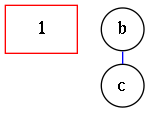

In [4]:
G=pgv.AGraph(ranksep='0.1')
G.add_node(1, color='red', shape="rect")
G.add_edge('b','c',color='blue')
G.layout() # default to neato
print(G.string())
draw_graph(G)

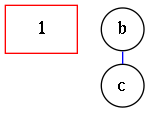

In [5]:
G.layout(prog='circo') # use dot
draw_graph(G)

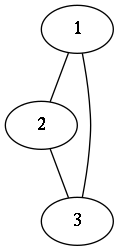

In [6]:
d={'1': {'2': {"label":"x", "shape":"rect"}, "3":None}, '2': {'1': None, '3': None}, '3': {'2': None}}
A=pgv.AGraph(d)
draw_graph(A)

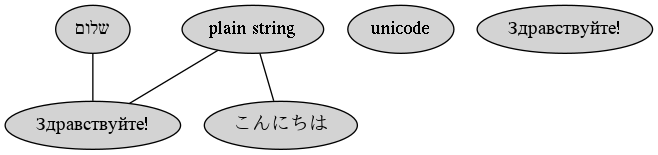

In [7]:
# specify UTF-8 encoding (it is the default)
A = pgv.AGraph(encoding="UTF-8")

A.node_attr["style"] = "filled"
# nodes, attributes, etc can be strings or unicode
A.add_node(1, label="plain string")
A.add_node(2, label="unicode")

# you can enter unicode text as
hello = "Здравствуйте!"
A.add_node(3, label=hello)

# or using unicode code points
hello = "\u0417\u0434\u0440\u0430\u0432\u0441\u0442\u0432\u0443\u0439\u0442\u0435!"
A.add_node(hello)  # unicode node label

goodbye = "До свидания"
A.add_edge(1, hello, key=goodbye)

A.add_edge("שלום", hello)
# A.add_edge(1,3,hello="こんにちは / ｺﾝﾆﾁﾊ")
A.add_edge(1, "こんにちは")
draw_graph(A)

strict digraph "" {
	graph [epsilon=0.001,
		rankdir=LR
	];
	node [label="\N"];
	1	 [color=red,
		label="centered\nleft\lright\r"];
	1 -> 2	 [color=green];
	1 -> 3;
	2 -> 3;
	5	 [color=blue];
	3 -> 5;
	3 -> 4;
	3 -> 6;
	4 -> 6;
}



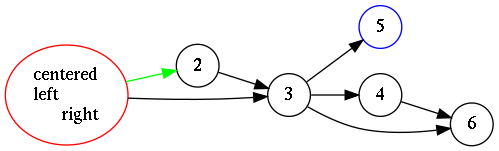

In [8]:
A = pgv.AGraph(directed=True, strict=True, rankdir="LR")
# add node 1 with color red
A.add_node(1, label=r'centered\nleft\lright\r', color="red")
A.add_node(5, color="blue")
# add some edges
A.add_edge(1, 2, color="green")
A.add_edge(2, 3)
A.add_edge(1, 3)
A.add_edge(3, 4)
A.add_edge(3, 5)
A.add_edge(3, 6)
A.add_edge(4, 6)
# adjust a graph parameter
A.graph_attr["epsilon"] = "0.001"
print(A.string())  # print dot file to standard output
A.layout("dot")  # layout with dot
draw_graph(A)

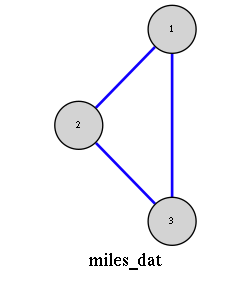

In [9]:
d={'1': {'2': {"label":"x", "shape":"rect"}, "3":None}, '2': {'1': None, '3': None}, '3': {'2': None}}
G=pgv.AGraph(d)
G.node_attr["shape"] = "circle"
G.node_attr["fixedsize"] = "true"
G.node_attr["fontsize"] = "8"
G.node_attr["style"] = "filled"
G.graph_attr["outputorder"] = "edgesfirst"
G.graph_attr["label"] = "miles_dat"
G.graph_attr["ratio"] = "1.0"
G.edge_attr["color"] = "#1100FF"
G.edge_attr["style"] = "setlinewidth(2)"
draw_graph(G)

/home/ingolf.lepenies/anaconda3/envs/sfem3/lib/python3.7/site-packages/pygraphviz/agraph.py:1341: RuntimeWarning: Warning: node '1', graph '' size too small for label

  warnings.warn(b"".join(errors).decode(self.encoding), RuntimeWarning)


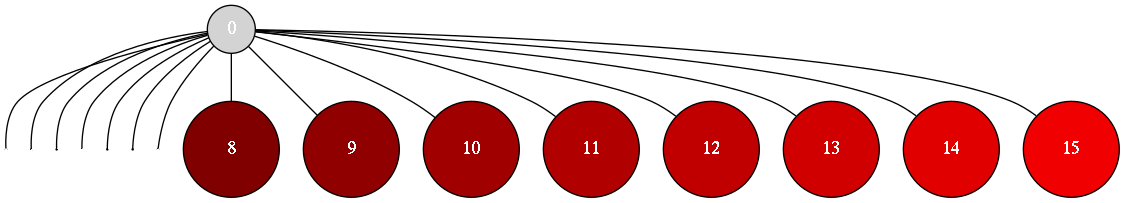

In [10]:
A = pgv.AGraph()

# set some default node attributes
A.node_attr["style"] = "filled"
A.node_attr["shape"] = "circle"
A.node_attr["fixedsize"] = "true"
A.node_attr["fontcolor"] = "#FFFFFF"

# make a star in shades of red
for i in range(1, 16):
    A.add_edge(0, i)
    n = A.get_node(i)
    n.attr["fillcolor"] = "#%2x0000" % (i * 16)
    n.attr["height"] = "%s" % (i / 16.0 + 0.5)
    n.attr["width"] = "%s" % (i / 16.0 + 0.5)
draw_graph(A)

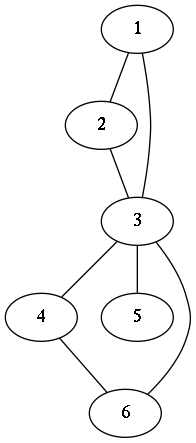

In [11]:
A = pgv.AGraph()
# add some edges
A.add_edge(1, 2)
A.add_edge(2, 3)
A.add_edge(1, 3)
A.add_edge(3, 4)
A.add_edge(3, 5)
A.add_edge(3, 6)
A.add_edge(4, 6)
# make a subgraph with rank='same'
# B = A.add_subgraph([4, 5, 6], name="s1", rank="same")
# B.graph_attr["rank"] = "same"
draw_graph(A)

In [12]:
sdict = {'!sdata_class': {'name': '!sdata_class',
  'value': 'Data',
  'unit': '-',
  'dtype': 'str',
  'description': 'sdata class',
  'label': '',
  'required': False},
 '#sdata_ctime': {'name': '!sdata_ctime',
  'value': '2021-01-20T23:30:52.034151+00:00',
  'unit': '-',
  'dtype': 'str',
  'description': 'creation date',
  'label': '',
  'required': False},
 '!sdata_mtime': {'name': '!sdata_mtime',
  'value': '2021-01-20T23:30:52.036132+00:00',
  'unit': '-',
  'dtype': 'str',
  'description': 'modification date',
  'label': '',
  'required': False},
 '!sdata_name': {'name': '!sdata_name',
  'value': 'otto',
  'unit': '-',
  'dtype': 'str',
  'description': 'name of the data object',
  'label': '',
  'required': False},
 '!sdata_parent': {'name': '!sdata_parent',
  'value': '',
  'unit': '-',
  'dtype': 'str',
  'description': 'uuid of the parent sdata object',
  'label': '',
  'required': False},
 '!sdata_project': {'name': '!sdata_project',
  'value': 'P1',
  'unit': '-',
  'dtype': 'str',
  'description': '',
  'label': '',
  'required': False},
 '!sdata_uuid': {'name': '!sdata_uuid',
  'value': '21b83703d98e38a7be2e50e38326d0ce',
  'unit': '-',
  'dtype': 'str',
  'description': 'Universally Unique Identifier',
  'label': '',
  'required': False},
 '!sdata_version': {'name': '!sdata_version',
  'value': '0.17.0',
  'unit': '-',
  'dtype': 'str',
  'description': 'sdata package version',
  'label': '',
  'required': False},
 'a': {'name': 'a',
  'value': 1,
  'unit': '-',
  'dtype': 'int',
  'description': '',
  'label': '',
  'required': False}}

In [13]:
data = sdata.Data(name="otto", 
                  uuid=sdata.uuid_from_str("otto"), 
                  table=pd.DataFrame({"a":[1,2,3]}),
                  description="Hallo\nSpencer",
                  project="P1")
data.metadata.add("a",1)
data.metadata.sdf

,name,value,dtype,unit,description,label,required
key,,,,,,,
!sdata_class,!sdata_class,Data,str,-,sdata class,,False
!sdata_ctime,!sdata_ctime,2021-02-01T21:49:41.514502+00:00,str,-,creation date,,False
!sdata_mtime,!sdata_mtime,2021-02-01T21:49:41.514699+00:00,str,-,modification date,,False
!sdata_name,!sdata_name,otto,str,-,name of the data object,,False
!sdata_parent,!sdata_parent,,str,-,uuid of the parent sdata object,,False
!sdata_project,!sdata_project,P1,str,-,,,False
!sdata_uuid,!sdata_uuid,21b83703d98e38a7be2e50e38326d0ce,str,-,Universally Unique Identifier,,False
!sdata_version,!sdata_version,0.17.0,str,-,sdata package version,,False


In [14]:
df = data.metadata.sdf[["name", "value"]].copy()
df.name.update(df.name.str.replace("!sdata_", ""))
sdict = dict(df.values)
uid = sdict.get("uuid")
sdict["uuids"] = f"{uid[:4]}.{uid[-4:]}"
sdict

{'class': 'Data',
 'ctime': '2021-02-01T21:49:41.514502+00:00',
 'mtime': '2021-02-01T21:49:41.514699+00:00',
 'name': 'otto',
 'parent': '',
 'project': 'P1',
 'uuid': '21b83703d98e38a7be2e50e38326d0ce',
 'version': '0.17.0',
 'uuids': '21b8.d0ce'}

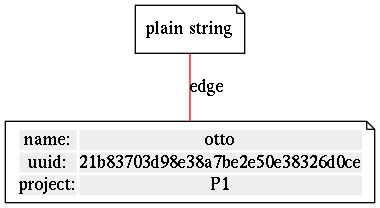

In [15]:
label = """<<TABLE BGCOLOR="white" border="0" cellpadding="0">
            <TR><TD BGCOLOR="#eeeeee">name:</TD><TD BGCOLOR="#eeeeee">{name}</TD></TR>
            <TR><TD BGCOLOR="#eeeeee">uuid:</TD><TD BGCOLOR="#eeeeee">{uuid}</TD></TR>
            <TR><TD BGCOLOR="#eeeeee">project:</TD><TD BGCOLOR="#eeeeee">{project}</TD></TR>
            </TABLE>>"""
A = pgv.AGraph(encoding="UTF-8")

A.node_attr["style"] = "filled"
A.node_attr["fillcolor"] = "white"
A.node_attr["shape"] = "note"
# nodes, attributes, etc can be strings or unicode
A.add_node(1, label="plain string")
A.add_node(2, label=label.format(**sdict))
A.add_edge(1,2, label="edge", color="red")
draw_graph(A)

In [16]:
print(A.to_string())

strict graph "" {
	graph [encoding="UTF-8"];
	node [fillcolor=white,
		label="\N",
		shape=note,
		style=filled
	];
	1	 [label="plain string"];
	2	 [label=<<TABLE BGCOLOR="white" border="0" cellpadding="0">
            <TR><TD BGCOLOR="#eeeeee">name:</TD><TD BGCOLOR="#eeeeee">otto</TD></TR>
            <TR><TD BGCOLOR="#eeeeee">uuid:</TD><TD BGCOLOR="#eeeeee">21b83703d98e38a7be2e50e38326d0ce</TD></TR>
            <TR><TD BGCOLOR="#eeeeee">project:</TD><TD BGCOLOR="#eeeeee">P1</TD></TR>
            </TABLE>>];
	1 -- 2	 [color=red,
		label="edge"];
}



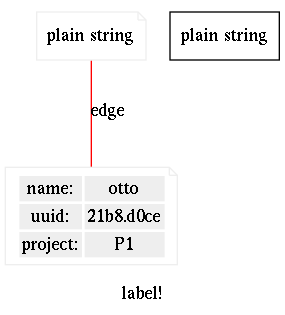

In [17]:
label = """<<TABLE BGCOLOR="white" border="0" cellpadding="2">
            <TR><TD BGCOLOR="#eeeeee">name:</TD><TD BGCOLOR="#eeeeee">{name}</TD></TR>
            <TR><TD BGCOLOR="#eeeeee">uuid:</TD><TD BGCOLOR="#eeeeee">{uuids}</TD></TR>
            <TR><TD BGCOLOR="#eeeeee">project:</TD><TD BGCOLOR="#eeeeee">{project}</TD></TR>
            </TABLE>>"""
A = pgv.AGraph(encoding="UTF-8")

node_attr = {"shape":"note", "fillcolor":"white", "color":"#eeeeee"}

# nodes, attributes, etc can be strings or unicode
A.add_node(1, label="plain string", **node_attr, distorssion=30)
A.add_node("1a", label="plain string", distorsion=-100, shape="rect")
A.add_node(2, label=label.format(**sdict), **node_attr)
A.add_edge(1,2, label="edge", color="red", edgeURL="http://heise.de")

A.graph_attr["outputorder"] = "edgesfirst"
A.graph_attr["label"] = "label!"
A.graph_attr["ratio"] = "1.0"
A.graph_attr["style"] = "filled"
draw_graph(A)

In [18]:
draw_graph_svg(A)

In [19]:
from IPython.display import SVG, display
def show_svg():
    display(SVG(url='http://upload.wikimedia.org/wikipedia/en/a/a4/Flag_of_the_United_States.svg'))
# show_svg()

In [20]:
def draw_graph_svg(g):
    return Image(g.draw(format='svg', prog='dot'))

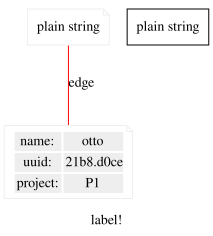

In [21]:
from IPython.display import SVG, display
def show_svg(g):
    display(SVG(g.draw(format='svg', prog='dot')))
show_svg(A)